# Model comparison — overview & scorecard

Entry point for **decision making**: effort, pipeline outcomes, a cross-dimension KPI scorecard comparing the models on one screen, and a ranking of every run from best to worst. Detailed evidence lives in `10_build`, `20_tests_coverage` and `30_code_metrics`. Iterations are independent samples; only iterations 1–6 are included.

In [1]:
STORY_ID = "CPD-LC-001-001"

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import tdd_results as tdd

tdd.setup_theme()
data = tdd.load_all(STORY_ID)
MODELS = tdd.discover_models(STORY_ID)
PAL = tdd.model_palette(MODELS)        # fixed model -> color, used everywhere
HUE = list(PAL)                        # fixed hue_order, used everywhere

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
print(f"story: {STORY_ID} | models: {MODELS}")
print("palette:", PAL)
if tdd.load_warnings:
    print(f"{len(tdd.load_warnings)} load warnings -> tdd.load_warnings")

story: CPD-LC-001-001 | models: ['Kimi-K2.5', 'grok-4.5']
palette: {'Kimi-K2.5': '#2a78d6', 'grok-4.5': '#1baf7a'}


## Iteration summary (master table)

One row per (model, iteration): final build/test/coverage/metrics outcomes,
pipeline stage statuses and attempt counts. `NaN` = the stage produced no
canonical result for that cell. This table backs every chart below.

In [3]:
summ = tdd.iteration_summary(STORY_ID, data)
display(summ.round(3))

,story,model,iteration,build_status,build_errors,build_warnings,test_status,total_tests,passed,failed,skipped,pass_rate,line_rate,branch_rate,median_mi,min_mi,max_cc,max_coupling,max_dit,n_types,pct_green_types,source_lines,executable_lines,tg_status,tg_test_methods,cg_status,cg_files_created,cg_files_modified,ref_status,ref_all_green,ref_loop_iterations,ref_n_remaining_violations,build_attempts,test_attempts,metrics_attempts
0,CPD-LC-001-001,Kimi-K2.5,1,success,0,0,success,24,24,0,0,1.0,0.652,0.900,72.5,54,10,21,1,24,0.917,561,73,success,21.0,success,10,14,partial,False,1.0,2,13,8,2
1,CPD-LC-001-001,Kimi-K2.5,2,success,0,0,success,24,24,0,0,1.0,0.551,0.857,71.0,56,5,19,1,25,0.920,576,72,success,21.0,success,10,12,success,True,1.0,0,12,5,3
2,CPD-LC-001-001,Kimi-K2.5,3,success,0,0,success,24,24,0,0,1.0,0.552,0.800,74.0,55,8,22,1,24,0.917,539,68,success,21.0,success,11,13,success,True,0.0,0,6,3,1
3,CPD-LC-001-001,Kimi-K2.5,4,success,0,0,success,24,24,0,0,1.0,0.569,0.889,74.0,55,8,18,1,25,0.920,577,67,success,17.0,success,0,1,partial,False,2.0,1,15,10,4
4,CPD-LC-001-001,Kimi-K2.5,5,success,0,0,success,24,24,0,0,1.0,0.546,0.800,72.5,55,5,15,1,22,0.909,533,66,success,21.0,success,8,13,partial,False,2.0,1,20,4,3
5,CPD-LC-001-001,Kimi-K2.5,6,success,0,0,success,24,24,0,0,1.0,0.545,0.900,74.0,57,8,21,1,23,0.913,493,68,success,21.0,success,10,9,partial,False,1.0,2,13,3,2
6,CPD-LC-001-001,grok-4.5,1,success,0,0,success,24,24,0,0,1.0,0.626,0.643,74.0,63,9,15,1,30,0.967,552,86,success,16.0,success,0,4,success,True,4.0,0,7,6,5
7,CPD-LC-001-001,grok-4.5,2,success,0,0,success,24,24,0,0,1.0,0.556,0.750,74.0,54,6,15,1,29,0.966,618,80,success,21.0,success,11,7,success,True,6.0,0,7,7,7
8,CPD-LC-001-001,grok-4.5,3,success,0,0,success,24,24,0,0,1.0,0.561,0.750,71.0,54,6,15,1,27,0.963,629,76,success,21.0,success,11,9,success,True,3.0,0,5,4,4
9,CPD-LC-001-001,grok-4.5,4,success,0,0,success,24,24,0,0,1.0,0.554,0.750,72.0,54,6,15,1,28,0.964,618,77,success,21.0,success,11,3,success,True,2.0,0,3,3,3


## Effort: executions per iteration

Every retry the agent needed before moving on, per result tree. Taller bars =
more friction. Compare models at the same iteration position.

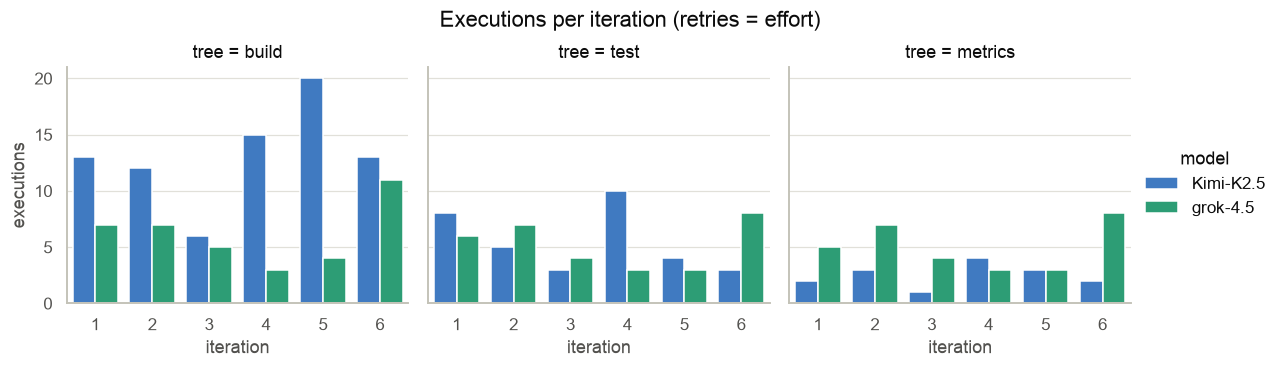

In [4]:
ac = pd.concat([
    tdd.attempt_counts(data["build"], "build"),
    tdd.attempt_counts(data["test"], "test"),
    tdd.attempt_counts(data["metrics_types"], "metrics"),
])
if ac.empty:
    print("No data for this section.")
else:
    g = sns.catplot(data=ac, kind="bar", x="iteration", y="n_attempts",
                    hue="model", col="tree", hue_order=HUE, palette=PAL,
                    height=3.2, aspect=1.1)
    g.set_axis_labels("iteration", "executions")
    g.figure.suptitle("Executions per iteration (retries = effort)", y=1.04)

## Effort distribution per model

Small samples (6 iterations/model), so every point is shown over the box.
A tight low box = the model converges with little friction.

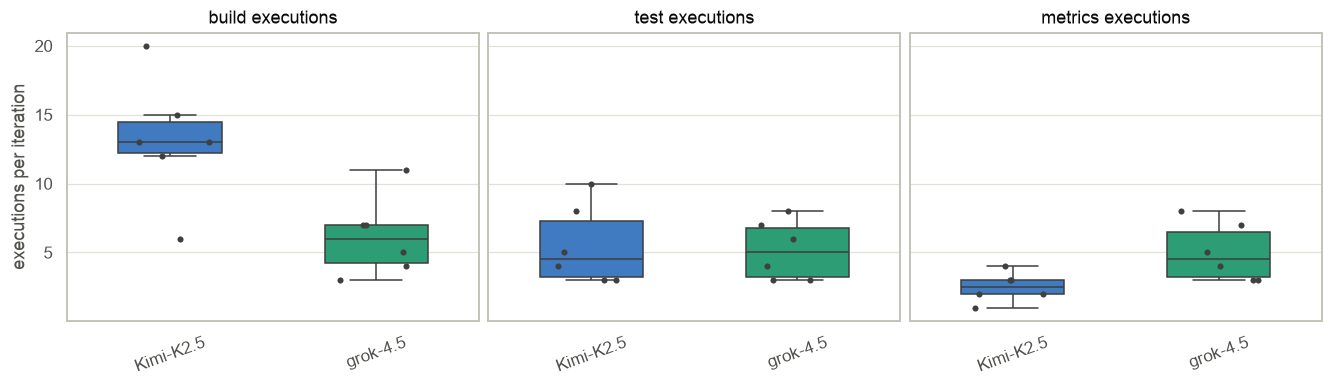

In [5]:
if ac.empty:
    print("No data for this section.")
else:
    trees = list(ac["tree"].unique())
    fig, axes = plt.subplots(1, len(trees), figsize=(4 * len(trees), 3.4), sharey=True)
    for ax, tree in zip(np.atleast_1d(axes), trees):
        sub = ac[ac["tree"] == tree]
        sns.boxplot(data=sub, x="model", y="n_attempts", hue="model", order=HUE,
                    hue_order=HUE, palette=PAL, legend=False, width=0.5,
                    showfliers=False, ax=ax)
        sns.stripplot(data=sub, x="model", y="n_attempts", order=HUE,
                      color=".25", size=4, jitter=0.2, ax=ax)
        ax.set_title(f"{tree} executions")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
    axes_flat = np.atleast_1d(axes)
    axes_flat[0].set_ylabel("executions per iteration")

## Pipeline stage outcomes per cell

One matrix per stage; each cell is (model, iteration). `S` = success,
`P` = partial, `F` = failure; gray = no result recorded.

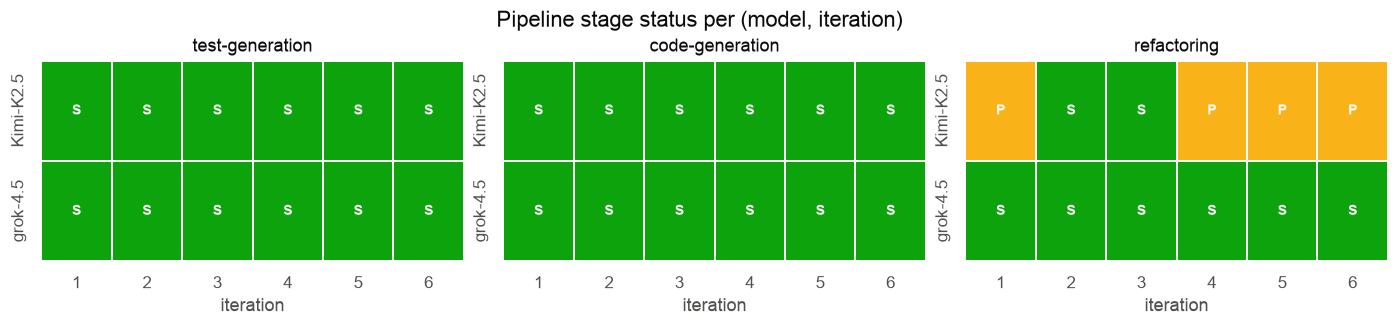

In [6]:
from matplotlib.colors import BoundaryNorm, ListedColormap

stages = data["stages"]
if stages.empty:
    print("No data for this section.")
else:
    order = ["test-generation", "code-generation", "refactoring"]
    code_map = {"failure": 0, "partial": 1, "success": 2}
    abbr = {"failure": "F", "partial": "P", "success": "S"}
    iters = sorted(stages["iteration"].unique())
    cmap = ListedColormap([tdd.STAGE_STATUS_COLORS["failure"],
                           tdd.STAGE_STATUS_COLORS["partial"],
                           tdd.STAGE_STATUS_COLORS["success"]])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)
    fig, axes = plt.subplots(1, len(order), figsize=(4.2 * len(order), 2.6))
    for ax, stage in zip(np.atleast_1d(axes), order):
        sub = stages[stages["stage"] == stage]
        grid = (sub.pivot(index="model", columns="iteration", values="status")
                   .reindex(index=HUE, columns=iters))
        sns.heatmap(grid.map(code_map.get), cmap=cmap, norm=norm, cbar=False,
                    annot=grid.map(lambda s: abbr.get(s, "")), fmt="",
                    linewidths=1, linecolor="white", ax=ax,
                    annot_kws={"fontsize": 9, "color": "white", "fontweight": "bold"})
        ax.set_facecolor("#f0efec")
        ax.set_title(stage)
        ax.set_ylabel("")
    fig.suptitle("Pipeline stage status per (model, iteration)", y=1.08)

## Refactoring: all-green achievement and loop cost

Left: how often the refactoring loop drove every metric flag to GREEN
(annotated with the raw fraction — n is small). Right: how many loop
iterations it took; points on the dashed line hit the budget ceiling.

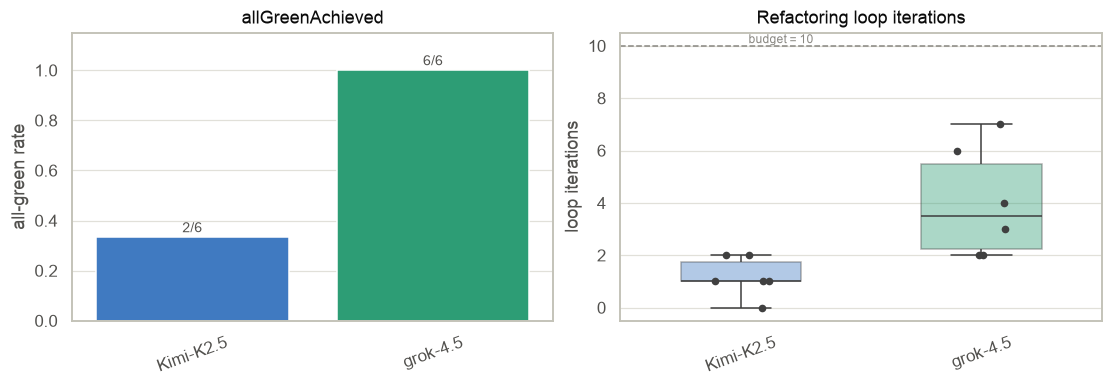

In [7]:
ref = data["stages"].query("stage == 'refactoring'") if not data["stages"].empty else data["stages"]
if ref.empty:
    print("No refactoring results.")
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

    ag = (ref.assign(all_green=ref["ref_all_green"].map({True: 1.0, False: 0.0}))
             .groupby("model")["all_green"].agg(rate="mean", achieved="sum", n="count")
             .reindex(HUE))
    sns.barplot(x=ag.index, y=ag["rate"], hue=ag.index, hue_order=HUE,
                palette=PAL, legend=False, ax=ax1)
    for i, (_, row) in enumerate(ag.iterrows()):
        ax1.text(i, row["rate"] + 0.02, f"{int(row['achieved'])}/{int(row['n'])}",
                 ha="center", fontsize=9, color=tdd.INK["secondary"])
    ax1.set_ylim(0, 1.15)
    ax1.set_ylabel("all-green rate")
    ax1.set_xlabel("")
    ax1.set_title("allGreenAchieved")
    ax1.tick_params(axis="x", rotation=20)

    sns.boxplot(data=ref, x="model", y="ref_loop_iterations", hue="model",
                order=HUE, hue_order=HUE, palette=PAL, legend=False,
                width=0.5, showfliers=False, boxprops={"alpha": 0.4}, ax=ax2)
    sns.stripplot(data=ref, x="model", y="ref_loop_iterations", order=HUE,
                  color=".25", size=5, jitter=0.15, ax=ax2)
    ceiling = ref["ref_max_loop_iterations"].max()
    if pd.notna(ceiling):
        ax2.axhline(ceiling, ls="--", color=tdd.INK["muted"], lw=1)
        ax2.text(0.02, ceiling, f" budget = {int(ceiling)}", va="bottom",
                 fontsize=8, color=tdd.INK["muted"])
    ax2.set_ylabel("loop iterations")
    ax2.set_xlabel("")
    ax2.set_title("Refactoring loop iterations")
    ax2.tick_params(axis="x", rotation=20)

## KPI scorecard

All dimensions on one screen. Color = per-column min-max normalization,
oriented so **darker = better** (columns marked ↓ are inverted: lower raw
value is better). Numbers are the **raw** values — read those for decisions;
color only ranks the three models per column.

,build success rate,build attempts ↓,test pass rate,tests emitted / intent,line coverage,branch coverage,median MI,% all-GREEN types,all-green rate,refactor loops ↓
model,,,,,,,,,,
Kimi-K2.5,1.0,13.167,1.0,0.968,0.569,0.858,73.25,0.916,0.333,1.167
grok-4.5,1.0,6.167,1.0,0.960,0.569,0.750,73.00,0.965,1.000,4.000


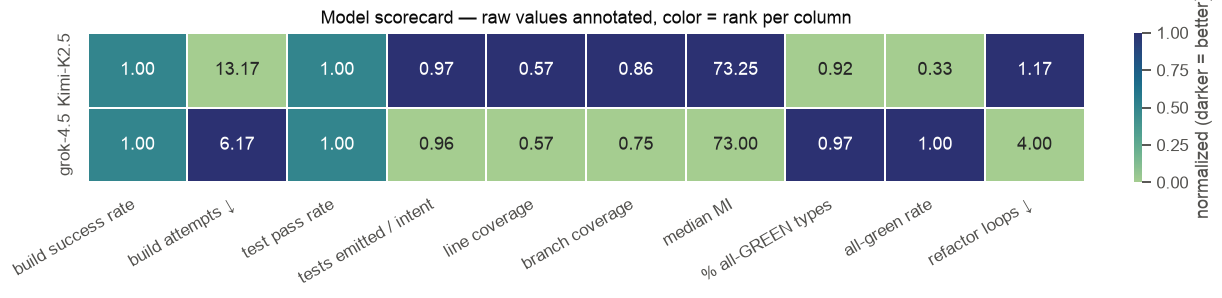

In [8]:
intents_total = data["intents"]["n_intents"].sum() if not data["intents"].empty else np.nan
by_model = summ.groupby("model")
kpis = pd.DataFrame({
    "build success rate": by_model["build_status"].agg(lambda s: s.dropna().eq("success").mean()),
    "build attempts ↓": by_model["build_attempts"].mean(),
    "test pass rate": by_model["pass_rate"].mean(),
    "tests emitted / intent": by_model["tg_test_methods"].mean() / intents_total,
    "line coverage": by_model["line_rate"].mean(),
    "branch coverage": by_model["branch_rate"].mean(),
    "median MI": by_model["median_mi"].median(),
    "% all-GREEN types": by_model["pct_green_types"].mean(),
    "all-green rate": by_model["ref_all_green"].agg(
        lambda s: s.map({True: 1.0, False: 0.0}).mean()),
    "refactor loops ↓": by_model["ref_loop_iterations"].mean(),
}).reindex(HUE)

norm = kpis.copy()
for col in norm:
    v = norm[col].astype(float)
    lo, hi = v.min(), v.max()
    n = (v - lo) / (hi - lo) if hi > lo else pd.Series(0.5, index=v.index)
    norm[col] = 1 - n if col.endswith("↓") else n

annot = kpis.map(lambda v: "n/a" if pd.isna(v) else f"{v:.2f}")
fig, ax = plt.subplots(figsize=(11, 2.6))
sns.heatmap(norm.astype(float), annot=annot, fmt="", cmap="crest",
            vmin=0, vmax=1, linewidths=1, linecolor="white",
            cbar_kws={"label": "normalized (darker = better)"}, ax=ax)
ax.set_facecolor("#f0efec")
ax.set_ylabel("")
ax.set_title("Model scorecard — raw values annotated, color = rank per column")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
display(kpis.round(3))

## Best run — all (model, iteration) runs ranked

Which single run of this story is the best? Every run is scored on the three
criteria, each a pillar of equally weighted components (`PILLAR_WEIGHTS`
changes the pillar mix):

- **build** — final build succeeds, few build errors, few build executions;
- **tests & coverage** — final pass rate, line and branch coverage. A run
  that produced no coverage evidence scores 0 there — no coverage *is* a
  result;
- **refactoring & quality** — share of all-GREEN types, median MI, all-green
  refactoring achieved, few remaining violations, few refactoring loop
  iterations, few metrics executions.

Components are min–max normalized across runs (↓ = lower is better, inverted;
flat columns count 0.5 for everyone; missing evidence scores 0), averaged per
pillar, and the composite is the weighted pillar mean — scores rank the runs
of **this story** relative to each other, they are not absolute grades.
Test-tree retries stay unscored on purpose: they are effort, visible above,
while criterion (b) scores result quality.

,model,iteration,composite,build,tests & coverage,refactoring & quality,build_status,build_errors,build_attempts,pass_rate,line_rate,branch_rate,median_mi,pct_green_types,ref_all_green,ref_n_remaining_violations,ref_loop_iterations,metrics_attempts
rank,,,,,,,,,,,,,,,,,,
1,grok-4.5,5,0.624,0.647,0.444,0.780,success,0,4,1.0,0.542,0.857,72.0,0.963,True,0,2.0,3
2,Kimi-K2.5,3,0.621,0.608,0.400,0.855,success,0,6,1.0,0.552,0.800,74.0,0.917,True,0,0.0,1
3,grok-4.5,1,0.606,0.588,0.422,0.806,success,0,7,1.0,0.626,0.643,74.0,0.967,True,0,4.0,5
4,grok-4.5,4,0.597,0.667,0.341,0.784,success,0,3,1.0,0.554,0.750,72.0,0.964,True,0,2.0,3
5,Kimi-K2.5,1,0.565,0.471,0.833,0.391,success,0,13,1.0,0.652,0.900,72.5,0.917,False,2,1.0,2
6,grok-4.5,3,0.556,0.627,0.364,0.677,success,0,5,1.0,0.561,0.750,71.0,0.963,True,0,3.0,4
7,grok-4.5,2,0.548,0.588,0.349,0.708,success,0,7,1.0,0.556,0.750,74.0,0.966,True,0,6.0,7
8,Kimi-K2.5,2,0.529,0.490,0.471,0.626,success,0,12,1.0,0.551,0.857,71.0,0.920,True,0,1.0,3
9,grok-4.5,6,0.526,0.510,0.402,0.667,success,0,11,1.0,0.574,0.750,74.0,0.968,True,0,7.0,8


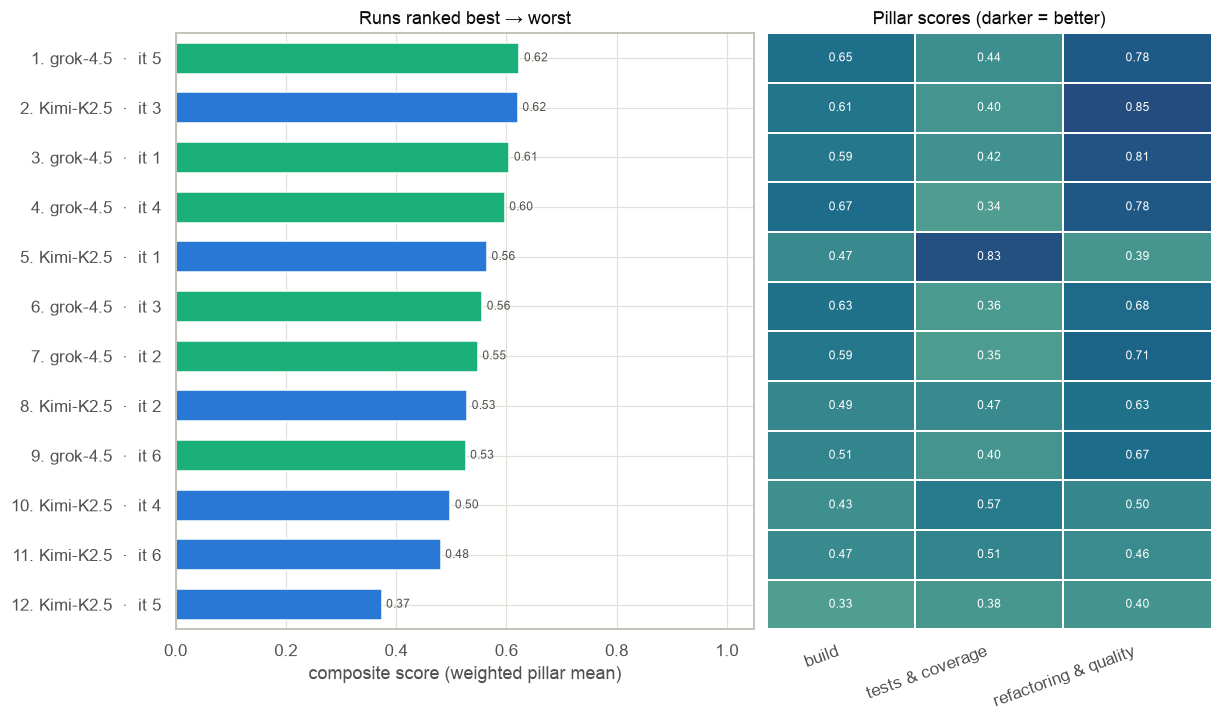

In [9]:
if summ.empty:
    print("No data for this section.")
else:
    LOW = "\u2193"  # suffix: lower raw value is better -> inverted when normalizing
    PILLAR_WEIGHTS = {"build": 1.0, "tests & coverage": 1.0, "refactoring & quality": 1.0}
    PILLARS = {
        "build": {
            "final build ok": (summ["build_status"] == "success").astype(float),
            f"build errors {LOW}": summ["build_errors"],
            f"build executions {LOW}": summ["build_attempts"],
        },
        "tests & coverage": {
            "pass rate": summ["pass_rate"],
            "line coverage": summ["line_rate"],
            "branch coverage": summ["branch_rate"],
        },
        "refactoring & quality": {
            "% all-GREEN types": summ["pct_green_types"],
            "median MI": summ["median_mi"],
            "all-green refactor": summ["ref_all_green"].map({True: 1.0, False: 0.0}),
            f"violations left {LOW}": summ["ref_n_remaining_violations"],
            f"refactor loops {LOW}": summ["ref_loop_iterations"],
            f"metrics executions {LOW}": summ["metrics_attempts"],
        },
    }

    def norm01(s, invert):
        """Min-max to [0, 1]; flat -> 0.5; missing evidence -> 0 (worst)."""
        v = pd.to_numeric(s, errors="coerce")
        lo, hi = v.min(), v.max()
        if pd.isna(lo):
            return pd.Series(0.0, index=v.index)
        n = (v - lo) / (hi - lo) if hi > lo else v.where(v.isna(), 0.5)
        return (1 - n if invert else n).fillna(0.0)

    detail_cols = ["build_status", "build_errors", "build_attempts",
                   "pass_rate", "line_rate", "branch_rate",
                   "median_mi", "pct_green_types", "ref_all_green",
                   "ref_n_remaining_violations", "ref_loop_iterations",
                   "metrics_attempts"]
    ranking = summ[["model", "iteration"] + detail_cols].copy()
    for pillar, comps in PILLARS.items():
        scored = pd.DataFrame({n: norm01(v, n.endswith(LOW)) for n, v in comps.items()})
        ranking[pillar] = scored.mean(axis=1)
    w = pd.Series(PILLAR_WEIGHTS)
    ranking["composite"] = (ranking[list(PILLARS)] * w).sum(axis=1) / w.sum()
    ranking = (ranking.sort_values(["composite", "model", "iteration"],
                                   ascending=[False, True, True])
                      .reset_index(drop=True))
    ranking.index = pd.RangeIndex(1, len(ranking) + 1, name="rank")

    labels = [f"{r}. {m}  \u00b7  it {i}" for r, m, i
              in zip(ranking.index, ranking["model"], ranking["iteration"])]
    y = np.arange(len(ranking)) + 0.5           # match heatmap row centers
    fig = plt.figure(figsize=(11, 0.42 * len(ranking) + 1.4))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.3, 1])

    ax1 = fig.add_subplot(gs[0])
    bars = ax1.barh(y, ranking["composite"], height=0.62,
                    color=[PAL[m] for m in ranking["model"]])
    ax1.bar_label(bars, fmt="%.2f", fontsize=8, color=tdd.INK["secondary"], padding=3)
    ax1.set_yticks(y, labels)
    ax1.set_ylim(len(ranking), 0)               # rank 1 on top
    ax1.set_xlim(0, 1.05)
    ax1.set_xlabel("composite score (weighted pillar mean)")
    ax1.set_title("Runs ranked best \u2192 worst")

    ax2 = fig.add_subplot(gs[1])
    sns.heatmap(ranking[list(PILLARS)].astype(float), cmap="crest", vmin=0, vmax=1,
                annot=True, fmt=".2f", linewidths=1, linecolor="white",
                yticklabels=False, cbar=False, annot_kws={"fontsize": 8}, ax=ax2)
    ax2.set_ylabel("")
    ax2.set_title("Pillar scores (darker = better)")
    plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

    front = ["model", "iteration", "composite"] + list(PILLARS)
    display(ranking[front + detail_cols].round(3))

## Sanity checks

In [10]:
fb = tdd.finals(data["build"])
if not fb.empty:
    assert fb.groupby(["story", "model", "iteration"]).size().max() == 1
    assert fb["ts"].notna().all()
if not data["coverage"].empty:
    assert data["coverage"]["line_rate"].between(0, 1).all()
assert summ["iteration"].max() <= 6, "iterations beyond 6 must be excluded"
assert len(ranking) == len(summ), "ranking must cover every (model, iteration) cell"
assert ranking["composite"].between(0, 1).all(), "composite scores must stay in [0, 1]"
print(f"sanity checks passed | {len(tdd.load_warnings)} load warnings")

sanity checks passed | 0 load warnings
